# Benchmark of the Library: Comparison with QMCPy

In this notebook, we benchmark our library on a practical numerical integration problem and compare some of its features with those of an existing Python library, **QMCPy**.

The goal is not only to check whether the methods implemented in our library give accurate approximations, but also to compare their behavior with a more established QMC library on methods that both libraries have in common.

The notebook is organized as follows:

- First, we compare the accuracy of the different sampling methods implemented in our library on the same test problem.
- Then, we compare our library with QMCPy on the methods available in both libraries, such as Uniform sampling, Sobol sequences, Halton sequences, and lattice rules.
- Finally, we benchmark the computational time required by both libraries to generate samples and approximate the integral.


### Internal Comparison of the Methods Implemented in the Library

The test problem used in this benchmark is the estimation of the expected loss of a regression model. A separate notebook already explains in detail how this problem can be formulated and solved using this library. See: [expected loss example notebook](https://github.com/Samuel-Vangu/qmc-lib/blob/main/examples/qmc_expected_loss_example.ipynb.ipynb).

The quantity we want to approximate is the expected squared loss

$$
R(\theta)
=
\mathbb{E}\left[
\left(
y_{\text{model}}(X)-Y
\right)^2
\right].
$$

After transforming the Gaussian random variables into uniform variables on the unit cube, this expectation can be written as the following integral over $[0,1]^4$:

$$
R(\theta)
=
\int_{[0,1]^4}
\left[
\theta_0+\theta_1z_1+\theta_2z_2+\theta_3z_3
-
\left(
\sin(z_1)+\frac12 z_2^2-0.3z_3+\sigma z_4
\right)
\right]^2
\,du,
$$

where

$$
z_i=\Phi^{-1}(u_i),
\qquad i=1,2,3,4.
$$

Here,

$$
du = du_1\,du_2\,du_3\,du_4,
$$

and $\Phi$ denotes the cumulative distribution function of the standard normal distribution.

For the parameters used in this example, the exact value of the integral is known:

$$
R(\theta)\approx 0.9018833028414803.
$$

This exact value will be used as a reference to compare the accuracy of the different sampling methods implemented in the library.



In [24]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qmc_lib.sampling.Halton import HaltonSampler
from qmc_lib.sampling.Kronecker import KroneckerSampler
from qmc_lib.sampling.LatinHypercube import LatinHypercubeSampler
from qmc_lib.sampling.LatticeRule import LatticeSampler
from qmc_lib.sampling.Sobol import SobolSampler
from qmc_lib.sampling.UniformSampler import UniformSampler
from qmc_lib.integration.Integrate import Integrator


# ============================================================
# Benchmark settings
# ============================================================

dimension = 4
sample_sizes = [2**n for n in range(10, 18)]
seed = 0

theta = np.array([0.0, 0.8, 0.0, -0.2])
sigma = 0.2


# ============================================================
# Exact value of the expected loss
# ============================================================

def exact_risk(theta, sigma=0.2):
    """
    Exact value of the expected squared loss.

    This closed-form expression is specific to the regression example
    considered in this notebook.
    """
    theta0, theta1, theta2, theta3 = theta

    term0 = (theta0 - 0.5) ** 2

    term1 = (
        theta1**2
        - 2.0 * theta1 * np.exp(-0.5)
        + 0.5 * (1.0 - np.exp(-2.0))
    )

    term2 = theta2**2 + 0.5
    term3 = (theta3 + 0.3) ** 2
    noise_term = sigma**2

    return term0 + term1 + term2 + term3 + noise_term


exact_value = exact_risk(theta, sigma)

print(f"Exact value: {exact_value:.15f}")


# ============================================================
# Integrand definition on the unit cube [0, 1]^4
# ============================================================

def unit_to_normal(u, eps=1e-12):
    """
    Map points from [0, 1]^d to standard normal variables.

    The clipping avoids infinite values when a coordinate is exactly
    equal to 0 or 1, since norm.ppf(0) = -inf and norm.ppf(1) = +inf.
    """
    u = np.clip(u, eps, 1.0 - eps)
    return norm.ppf(u)


def true_function(x):
    """
    True regression function.

    Parameters
    ----------
    x : ndarray of shape (3,)
        Gaussian input vector.

    Returns
    -------
    float
        Value of the true regression function.
    """
    return np.sin(x[0]) + 0.5 * x[1]**2 - 0.3 * x[2]


def model_function(x, theta):
    """
    Linear regression model.

    Parameters
    ----------
    x : ndarray of shape (3,)
        Gaussian input vector.

    theta : ndarray of shape (4,)
        Model parameter vector.

    Returns
    -------
    float
        Model prediction.
    """
    return (
        theta[0]
        + theta[1] * x[0]
        + theta[2] * x[1]
        + theta[3] * x[2]
    )


def f(u):
    """
    Integrand defined on [0, 1]^4.

    The first three coordinates are transformed into the Gaussian input X.
    The fourth coordinate is transformed into the Gaussian noise.

    This function takes one point u of shape (4,) and returns one scalar.
    """
    z = unit_to_normal(u)

    x = z[:3]
    noise = sigma * z[3]

    y_pred = model_function(x, theta)
    y_obs = true_function(x) + noise

    return (y_pred - y_obs) ** 2


# ============================================================
# Internal benchmark of the sampling methods
# ============================================================

samplers = {
    "Halton": HaltonSampler,
    "Sobol": SobolSampler,
    "Kronecker": KroneckerSampler,
    "LHS": LatinHypercubeSampler,
    "Lattice": LatticeSampler,
    "Uniform": UniformSampler,
}

# Dictionary used to store the absolute error for each method.
errors = {method: [] for method in samplers}


for n in sample_sizes:
    print(f"Running benchmark with n_samples = {n}")

    for method_name, SamplerClass in samplers.items():
        # Generate points in the unit cube [0, 1]^4.
        samples = SamplerClass(
            dimension=dimension,
            n_samples=n,
            seed=seed,
        ).generate()

        # Approximate the integral using the generated samples.
        estimate = Integrator(
            f=f,
            samples=samples,
        ).compute()

        # Store the absolute error with respect to the exact value.
        absolute_error = abs(estimate - exact_value)
        errors[method_name].append(absolute_error)

Exact value: 0.901883302841480
Running benchmark with n_samples = 1024
Running benchmark with n_samples = 2048
Running benchmark with n_samples = 4096
Running benchmark with n_samples = 8192
Running benchmark with n_samples = 16384
Running benchmark with n_samples = 32768
Running benchmark with n_samples = 65536
Running benchmark with n_samples = 131072


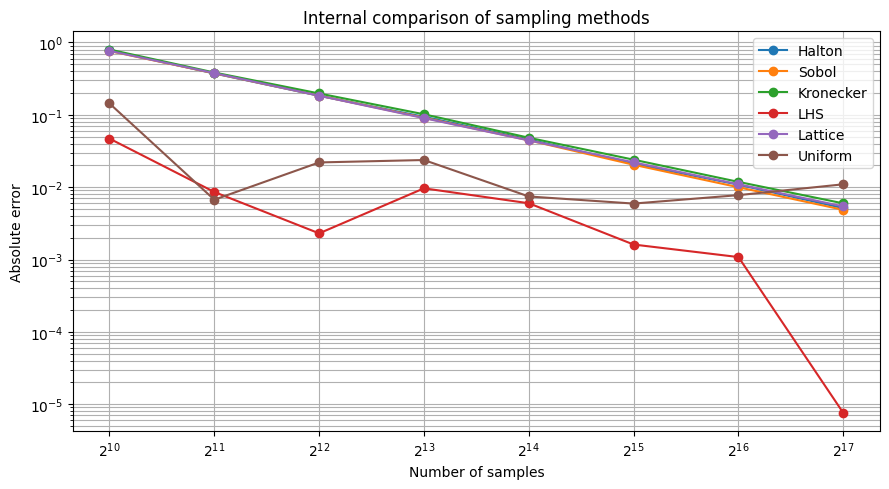

In [25]:
plt.figure(figsize=(9, 5))

for method_name, method_errors in errors.items():
    plt.plot(sample_sizes, method_errors, marker="o", label=method_name)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Absolute error")
plt.title("Internal comparison of sampling methods")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

The plot compares the absolute error of the different sampling methods implemented in the library. The error is shown for increasing numbers of samples, using a logarithmic scale on both axes.

The QMC methods generally show a decreasing error as the number of samples increases, which confirms that the estimators converge toward the exact value. Uniform sampling is less stable and oscillates more, as expected for a purely random method.

For this particular test problem, Latin Hypercube Sampling achieves the smallest error at the largest sample size. However, this result should not be interpreted as a general ranking of the methods, since the performance depends on the integrand, the dimension, and the number of samples.

# Comparison with QMCPy

After comparing the sampling methods implemented in our own library, we now compare some of them with equivalent methods provided by **QMCPy**, an existing Python library dedicated to Monte Carlo and quasi-Monte Carlo integration.

The goal of this section is not to claim that one library is universally better than the other. Instead, we want to check whether our implementations give numerical results that are consistent with those obtained from an established QMC library.

To make the comparison fair, we use the same test problem, the same exact reference value, and the same sample sizes for both libraries. We focus on the methods that are available in both libraries, such as Uniform sampling, Sobol sequences, Halton sequences, and lattice rules.

In this section, we first compare the accuracy of the estimators by measuring their absolute error with respect to the exact value of the integral. The computational time will be studied separately in the next section.

In [26]:
import pandas as pd
import qmcpy as qp

from qmc_lib.sampling.Halton import HaltonSampler
from qmc_lib.sampling.LatticeRule import LatticeSampler
from qmc_lib.sampling.Sobol import SobolSampler
from qmc_lib.sampling.UniformSampler import UniformSampler
from qmc_lib.integration.Integrate import Integrator


# ============================================================
# Comparison between qmc_lib and QMCPy
# ============================================================
#
# We compare the two libraries on the same integration problem:
#
#     R(theta) = integral over [0,1]^4 of f(u) du
#
# The exact value is known, so we can compare the absolute errors.
#
# For fairness, both libraries generate the same number of points,
# and the same integrand f is used to compute the final estimate.
# ============================================================


# Methods available in both libraries.
# The key is the common method name used in the final table.
# Each value contains:
#   - the sampler class from qmc_lib
#   - the sampler class from QMCPy
common_methods = {
    "Uniform": {
        "qmc_lib": UniformSampler,
        "QMCPy": qp.IIDStdUniform,
    },
    "Sobol": {
        "qmc_lib": SobolSampler,
        "QMCPy": qp.Sobol,
    },
    "Halton": {
        "qmc_lib": HaltonSampler,
        "QMCPy": qp.Halton,
    },
    "Lattice": {
        "qmc_lib": LatticeSampler,
        "QMCPy": qp.Lattice,
    },
}


def generate_qmc_lib_samples(SamplerClass, dimension, n_samples, seed):
    """
    Generate samples using qmc_lib.

    Parameters
    ----------
    SamplerClass : class
        Sampling class from qmc_lib.

    dimension : int
        Dimension of the integration domain.

    n_samples : int
        Number of sample points.

    seed : int
        Random seed.

    Returns
    -------
    ndarray
        Array of shape (n_samples, dimension).
    """
    return SamplerClass(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    ).generate()


def generate_qmcpy_samples(SamplerClass, dimension, n_samples, seed):
    """
    Generate samples using QMCPy.

    QMCPy samplers use the method gen_samples(n) to generate
    n points in the unit cube.

    Parameters
    ----------
    SamplerClass : class
        Sampling class from QMCPy.

    dimension : int
        Dimension of the integration domain.

    n_samples : int
        Number of sample points.

    seed : int
        Random seed.

    Returns
    -------
    ndarray
        Array of shape (n_samples, dimension).
    """
    sampler = SamplerClass(
        dimension=dimension,
        seed=seed,
    )

    return sampler.gen_samples(n_samples)


def compute_estimate(samples):
    """
    Approximate the integral using the same Integrator class
    for both qmc_lib samples and QMCPy samples.

    This keeps the comparison focused on the generated point sets.
    """
    return Integrator(
        f=f,
        samples=samples,
    ).compute()


# ============================================================
# Run the accuracy comparison
# ============================================================

comparison_rows = []

for n in sample_sizes:
    print(f"Running comparison with n_samples = {n}")

    for method_name, samplers in common_methods.items():

        # ------------------------------------------------------------
        # qmc_lib estimate
        # ------------------------------------------------------------
        qmc_lib_samples = generate_qmc_lib_samples(
            SamplerClass=samplers["qmc_lib"],
            dimension=dimension,
            n_samples=n,
            seed=seed,
        )

        qmc_lib_estimate = compute_estimate(qmc_lib_samples)
        qmc_lib_error = abs(qmc_lib_estimate - exact_value)

        comparison_rows.append(
            {
                "library": "qmc_lib",
                "method": method_name,
                "n_samples": n,
                "estimate": qmc_lib_estimate,
                "absolute_error": qmc_lib_error,
            }
        )

        # ------------------------------------------------------------
        # QMCPy estimate
        # ------------------------------------------------------------
        qmcpy_samples = generate_qmcpy_samples(
            SamplerClass=samplers["QMCPy"],
            dimension=dimension,
            n_samples=n,
            seed=seed,
        )

        qmcpy_estimate = compute_estimate(qmcpy_samples)
        qmcpy_error = abs(qmcpy_estimate - exact_value)

        comparison_rows.append(
            {
                "library": "QMCPy",
                "method": method_name,
                "n_samples": n,
                "estimate": qmcpy_estimate,
                "absolute_error": qmcpy_error,
            }
        )


# Store the results in a DataFrame.
df_comparison = pd.DataFrame(comparison_rows)



Running comparison with n_samples = 1024
Running comparison with n_samples = 2048
Running comparison with n_samples = 4096
Running comparison with n_samples = 8192
Running comparison with n_samples = 16384
Running comparison with n_samples = 32768
Running comparison with n_samples = 65536
Running comparison with n_samples = 131072


In [28]:
df_comparison_pivot = df_comparison.pivot_table(
    index=["method", "n_samples"],
    columns="library",
    values="absolute_error",
)

df_comparison_pivot

library               QMCPy   qmc_lib
method  n_samples                    
Halton  1024       0.040387  0.781681
        2048       0.018990  0.373049
        4096       0.005248  0.183294
        8192       0.006810  0.093938
        16384      0.005234  0.045647
        32768      0.000322  0.021097
        65536      0.000841  0.010819
        131072     0.000042  0.005137
Lattice 1024       0.006065  0.765586
        2048       0.004234  0.377094
        4096       0.003385  0.183829
        8192       0.000701  0.090002
        16384      0.000546  0.044261
        32768      0.001179  0.022051
        65536      0.000289  0.010961
        131072     0.000025  0.005417
Sobol   1024       0.046779  0.762967
        2048       0.028429  0.374911
        4096       0.010098  0.184321
        8192       0.001495  0.091145
        16384      0.000281  0.044426
        32768      0.000779  0.020404
        65536      0.000192  0.009976
        131072     0.000266  0.004856
Uniform 1024       0.070324  0.143749
        2048       0.055542  0.006704
        4096       0.009899  0.021972
        8192       0.030212  0.023729
        16384      0.002431  0.007437
        32768      0.010741  0.005931
        65536      0.005300  0.007758
        131072     0.010142  0.010956

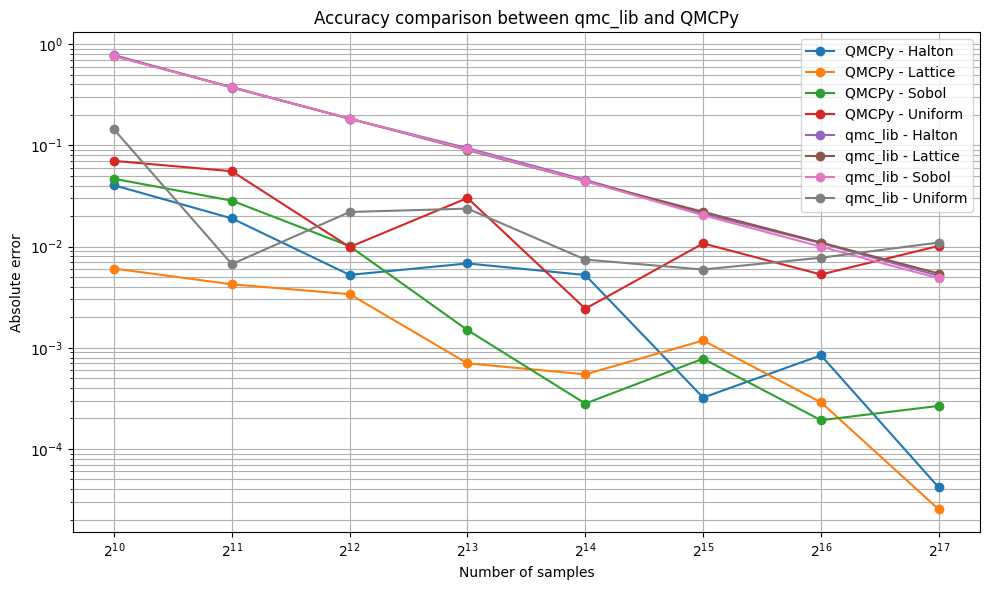

In [29]:
plt.figure(figsize=(10, 6))

for (library, method), group in df_comparison.groupby(["library", "method"]):
    label = f"{library} - {method}"

    plt.plot(
        group["n_samples"],
        group["absolute_error"],
        marker="o",
        label=label,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Absolute error")
plt.title("Accuracy comparison between qmc_lib and QMCPy")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

The comparison shows that QMCPy generally achieves smaller errors, especially for Sobol and lattice rules at large sample sizes. However, the difference is not overwhelming for all methods. In particular, the results obtained with qmc_lib remain of the same order of magnitude for several methods, and the error decreases globally as the number of samples increases.

This suggests that the implementations in qmc_lib are coherent, even if QMCPy benefits from more mature and optimized implementations, possibly including better parameters, randomizations, or scrambling techniques.

# Comparing Computational Time

After comparing the accuracy of the two libraries, we now focus on computational time.

In this section, we do not benchmark the full integration process. Since both libraries are evaluated using the same integrand, the time required to evaluate the function is almost the same in both cases. Therefore, the most relevant quantity to compare is the **sample generation time**.

The goal is to measure how long each library takes to generate point sets for the methods they have in common: Uniform sampling, Sobol sequences, Halton sequences, and lattice rules.

We run the benchmark for several dimensions and several sample sizes. The timings are measured using `pyperf`, which provides more reliable measurements than a simple manual timing procedure.

To summarize the results clearly, we compute two averaged views:

- First, we average over the dimensions and over the common methods, and plot the mean generation time as a function of the number of samples.
- Then, we average over the sample sizes and over the common methods, and plot the mean generation time as a function of the dimension.

This gives two global timing plots:

1. generation time vs sample size;
2. generation time vs dimension.

These plots provide a compact view of how the two libraries scale when the number of generated points and the dimension increase.

In [1]:
def benchmark_function(points):
    """
    Vectorized benchmark function.

    Parameters
    ----------
    points : ndarray of shape (n_samples, dimension)
        Points in the unit cube [0,1]^d.

    Returns
    -------
    values : ndarray of shape (n_samples,)
        Function values at the sample points.
    """
    return np.prod(1.0 / (1.0 + points), axis=1)


def exact_integral(dimension):
    """
    Exact value of the integral of the benchmark function over [0,1]^d.
    """
    return np.log(2.0) ** dimension

In [2]:
def benchmark_function_single(x):
    """
    Non-vectorized version used with the Integrator class.
    """
    return np.prod(1.0 / (1.0 + x))

In [3]:
dimensions = [2, 4, 8, 16, 32, 64, 128]
sample_sizes = [2**m for m in range(10, 17)]

In [4]:
# ============================================================
# QMCPy benchmark functions
# ============================================================

def benchmark_qmcpy_uniform(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.IIDStdUniform,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmcpy_sobol(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.Sobol,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmcpy_halton(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.Halton,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmcpy_lattice(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.Lattice,
        dimension,
        n_samples,
        seed,
    )


# ============================================================
# qmc_lib benchmark functions
# ============================================================

def benchmark_qmc_lib_uniform(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        UniformSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_sobol(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        SobolSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_halton(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        HaltonSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_lattice(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        LatticeSampler,
        dimension,
        n_samples,
        seed,
    )

In [3]:
%%writefile benchmark_sampling.py

import qmcpy as qp

from qmc_lib.sampling.Sobol import SobolSampler
from qmc_lib.sampling.Halton import HaltonSampler
from qmc_lib.sampling.LatticeRule import LatticeSampler
from qmc_lib.sampling.UniformSampler import UniformSampler


# ============================================================
# Generic generation functions
# ============================================================

def generate_qmcpy_samples(sampler_class, dimension, n_samples, seed):
    """
    Generate samples with QMCPy.

    This generic function works for QMCPy samplers that accept
    a seed argument, such as Sobol, Halton and IIDStdUniform.
    """
    sampler = sampler_class(
        dimension=dimension,
        seed=seed,
    )

    return sampler.gen_samples(n_samples)


def generate_qmc_lib_samples(sampler_class, dimension, n_samples, seed):
    """
    Generate samples with qmc_lib.
    """
    sampler = sampler_class(
        dimension=dimension,
        n_samples=n_samples,
        seed=seed,
    )

    return sampler.generate()


# ============================================================
# QMCPy benchmark functions
# ============================================================

def benchmark_qmcpy_sobol(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.Sobol,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmcpy_halton(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.Halton,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmcpy_lattice(dimension, n_samples, seed=0):
    """
    Generate Lattice points with QMCPy.

    We do not pass the seed here because, depending on the QMCPy
    version, Lattice may not accept the same seed argument as
    Sobol or Halton.
    """
    sampler = qp.Lattice(dimension=dimension)
    return sampler.gen_samples(n_samples)


def benchmark_qmcpy_uniform(dimension, n_samples, seed=0):
    return generate_qmcpy_samples(
        qp.IIDStdUniform,
        dimension,
        n_samples,
        seed,
    )


# ============================================================
# qmc_lib benchmark functions
# ============================================================

def benchmark_qmc_lib_sobol(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        SobolSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_halton(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        HaltonSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_lattice(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        LatticeSampler,
        dimension,
        n_samples,
        seed,
    )


def benchmark_qmc_lib_uniform(dimension, n_samples, seed=0):
    return generate_qmc_lib_samples(
        UniformSampler,
        dimension,
        n_samples,
        seed,
    )

Overwriting benchmark_sampling.py


In [1]:
import os
import sys
import subprocess

# ============================================================
# Benchmark grid
# ============================================================

dimensions = [2, 8, 32, 128]
sample_sizes = [2**10, 2**12, 2**14, 2**16]
seed = 0

# Common methods between qmc_lib and QMCPy
methods = [ "lattice","sobol", "halton", "uniform"]

# ============================================================
# pyperf settings
# ============================================================

processes = 10
values = 5
min_time = 0.2

results_dir = "pyperf_results"
os.makedirs(results_dir, exist_ok=True)


for method in methods:
    for dimension in dimensions:
        for n_samples in sample_sizes:
            print("=" * 80)
            print(
                f"Benchmark: {method} | "
                f"dimension={dimension} | n_samples={n_samples}"
            )
            print("=" * 80)

            qmcpy_file = os.path.join(
                results_dir,
                f"qmcpy_{method}_dim{dimension}_n{n_samples}.json"
            )

            qmc_lib_file = os.path.join(
                results_dir,
                f"qmc_lib_{method}_dim{dimension}_n{n_samples}.json"
            )

            # pyperf refuses to overwrite existing JSON files.
            for file in [qmcpy_file, qmc_lib_file]:
                if os.path.exists(file):
                    os.remove(file)

            # Function names in benchmark_sampling.py
            qmcpy_function = f"benchmark_qmcpy_{method}"
            qmc_lib_function = f"benchmark_qmc_lib_{method}"

            # ------------------------------------------------------------
            # QMCPy benchmark
            # ------------------------------------------------------------
            subprocess.run(
                [
                    sys.executable,
                    "-m", "pyperf", "timeit",
                    "-s", f"from benchmark_sampling import {qmcpy_function}",
                    f"{qmcpy_function}({dimension}, {n_samples}, {seed})",
                    "-o", qmcpy_file,
                    "-p", str(processes),
                    "-n", str(values),
                    "--min-time", str(min_time),
                ],
                check=True,
            )

            # ------------------------------------------------------------
            # qmc_lib benchmark
            # ------------------------------------------------------------
            subprocess.run(
                [
                    sys.executable,
                    "-m", "pyperf", "timeit",
                    "-s", f"from benchmark_sampling import {qmc_lib_function}",
                    f"{qmc_lib_function}({dimension}, {n_samples}, {seed})",
                    "-o", qmc_lib_file,
                    "-p", str(processes),
                    "-n", str(values),
                    "--min-time", str(min_time),
                ],
                check=True,
            )

            # ------------------------------------------------------------
            # Direct comparison
            # ------------------------------------------------------------
            subprocess.run(
                [
                    sys.executable,
                    "-m", "pyperf", "compare_to",
                    qmcpy_file,
                    qmc_lib_file,
                    "--table",
                ],
                check=True,
            )

Benchmark: lattice | dimension=2 | n_samples=1024
Benchmark: lattice | dimension=2 | n_samples=4096
Benchmark: lattice | dimension=2 | n_samples=16384
Benchmark: lattice | dimension=2 | n_samples=65536
Benchmark: lattice | dimension=8 | n_samples=1024
Benchmark: lattice | dimension=8 | n_samples=4096
Benchmark: lattice | dimension=8 | n_samples=16384
Benchmark: lattice | dimension=8 | n_samples=65536
Benchmark: lattice | dimension=32 | n_samples=1024
Benchmark: lattice | dimension=32 | n_samples=4096
Benchmark: lattice | dimension=32 | n_samples=16384
Benchmark: lattice | dimension=32 | n_samples=65536
Benchmark: lattice | dimension=128 | n_samples=1024
Benchmark: lattice | dimension=128 | n_samples=4096
Benchmark: lattice | dimension=128 | n_samples=16384
Benchmark: lattice | dimension=128 | n_samples=65536
Benchmark: sobol | dimension=2 | n_samples=1024
Benchmark: sobol | dimension=2 | n_samples=4096
Benchmark: sobol | dimension=2 | n_samples=16384
Benchmark: sobol | dimension=2 | n_

In [6]:
import os
import pyperf
import pandas as pd
import matplotlib.pyplot as plt

dimensions = [2, 8, 32, 128]
sample_sizes = [2**10, 2**12, 2**14, 2**16]
methods = ["sobol", "lattice", "halton", "uniform"]

results_dir = "pyperf_results"

rows = []

for method in methods:
    for dimension in dimensions:
        for n_samples in sample_sizes:
            for library in ["qmcpy", "qmc_lib"]:
                filename = os.path.join(
                    results_dir,
                    f"{library}_{method}_dim{dimension}_n{n_samples}.json"
                )

                if not os.path.exists(filename):
                    print(f"Missing file: {filename}")
                    continue

                suite = pyperf.BenchmarkSuite.load(filename)
                benchmark = suite.get_benchmarks()[0]

                rows.append(
                    {
                        "library": library,
                        "method": method,
                        "dimension": dimension,
                        "n_samples": n_samples,
                        "mean_time": benchmark.mean(),
                        "std_time": benchmark.stdev(),
                    }
                )

df_time = pd.DataFrame(rows)


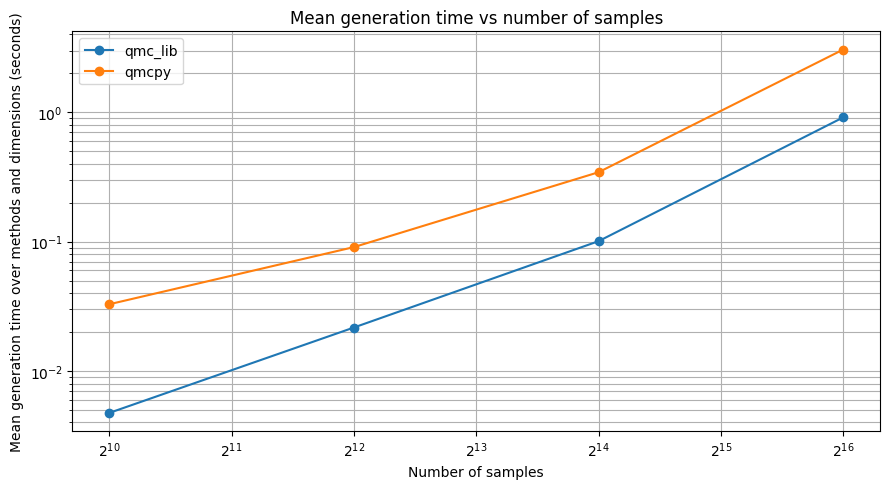

In [7]:
df_vs_samples = (
    df_time
    .groupby(["library", "n_samples"], as_index=False)
    .agg(
        mean_time=("mean_time", "mean"),
        std_time=("mean_time", "std"),
    )
)

plt.figure(figsize=(9, 5))

for library, group in df_vs_samples.groupby("library"):
    plt.plot(
        group["n_samples"],
        group["mean_time"],
        marker="o",
        label=library,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Mean generation time over methods and dimensions (seconds)")
plt.title("Mean generation time vs number of samples")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

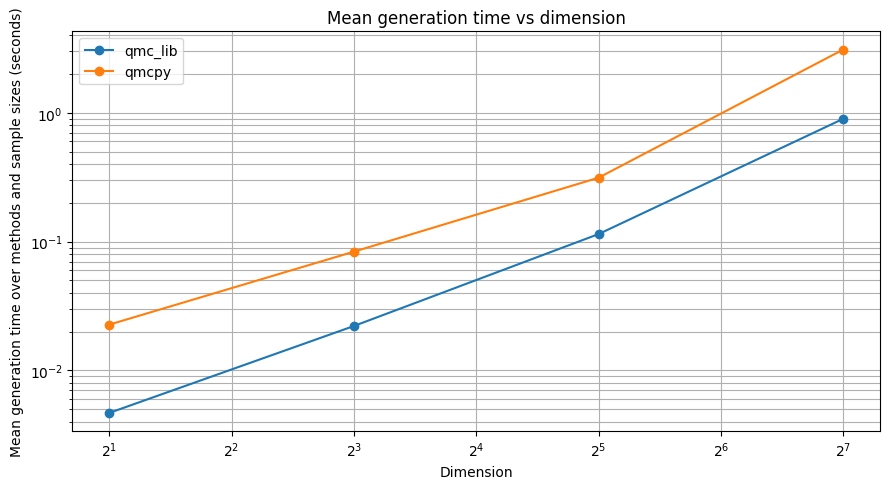

In [8]:
df_vs_dimension = (
    df_time
    .groupby(["library", "dimension"], as_index=False)
    .agg(
        mean_time=("mean_time", "mean"),
        std_time=("mean_time", "std"),
    )
)

plt.figure(figsize=(9, 5))

for library, group in df_vs_dimension.groupby("library"):
    plt.plot(
        group["dimension"],
        group["mean_time"],
        marker="o",
        label=library,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Dimension")
plt.ylabel("Mean generation time over methods and sample sizes (seconds)")
plt.title("Mean generation time vs dimension")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion

The two timing plots show that the generation time increases with both the number of samples and the dimension. This behavior is expected, since larger and higher-dimensional point sets require more values to be generated.

In this benchmark, `qmc_lib` is consistently faster than QMCPy for point generation. This suggests that the implementations in `qmc_lib` are lightweight and have a lower computational overhead. QMCPy, on the other hand, provides a more general and mature framework, which may introduce additional cost but also gives access to more advanced QMC tools.

These results should be interpreted together with the accuracy benchmark: `qmc_lib` is faster for basic generation, while QMCPy often gives stronger numerical performance. This reflects the main purpose of `qmc_lib`: providing clear, explicit and pedagogical implementations of Monte Carlo and Quasi-Monte Carlo methods.